# EDA e Treinamento dos Modelos de ML
## Pipeline de Dados Governamentais do Ceará — Trabalho Final

Este notebook documenta:
1. Análise exploratória (EDA) sobre a camada Gold (Data Warehouse dimensional);
2. Treinamento e avaliação do **Modelo 1** — detecção de anomalias contratuais (Isolation Forest);
3. Treinamento e avaliação do **Modelo 2** — previsão de pagamentos trimestrais por órgão (XGBoost, regressão quantílica).

Pré-requisito: as DAGs `dag_bronze_extract` → `dag_silver_transform` → `dag_gold_load` já devem
ter sido executadas com sucesso, populando o Data Warehouse (`dw.*`).


In [1]:
import sys
sys.path.append("..")  # permite importar o pacote `src` e `models` a partir de notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.loaders.dw_loader import connect_dw

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format


## 1. Análise Exploratória (EDA)

In [2]:
conn = connect_dw()

fato_contrato = pd.read_sql("""
    SELECT fc.*, dm.descricao_modalidade, dm.descricao_tipo, dc.nome AS nome_credor,
           dorg.nome AS nome_orgao, dt.data AS data_assinatura
    FROM dw.fato_contrato fc
    LEFT JOIN dw.dim_modalidade dm ON dm.sk_modalidade = fc.sk_modalidade
    LEFT JOIN dw.dim_credor dc ON dc.sk_credor = fc.sk_credor
    LEFT JOIN dw.dim_orgao dorg ON dorg.sk_orgao = fc.sk_orgao
    LEFT JOIN dw.dim_tempo dt ON dt.sk_tempo = fc.sk_tempo_assinatura
""", conn)
fato_contrato["data_assinatura"] = pd.to_datetime(fato_contrato["data_assinatura"])  # psycopg2 devolve DATE como object

print(f"{len(fato_contrato):,} contratos carregados do DW")
fato_contrato.head()


/tmp/ipykernel_339/2058322918.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fato_contrato = pd.read_sql("""


31,168 contratos carregados do DW


,sk_contrato,id_contrato_origem,num_contrato,sk_tempo_assinatura,sk_credor,sk_orgao,sk_modalidade,valor_contratado,valor_empenhado,valor_pago,...,flag_emergency,dias_vigencia,historico_credor_infringement,score_anomalia,ano,descricao_modalidade,descricao_tipo,nome_credor,nome_orgao,data_assinatura
0,93,640810,None,18,7038,49.00,1.00,957.60,957.60,957.60,...,False,338.00,0,0.03,2026,DISPENSA,DESPESA.SEM.INSTRUMENTO.CONTRATUAL,EDUQUE & BRINQUE EIRELI,EEMTI GOVERNADOR ADAUTO BEZERRA,2026-01-27
1,94,641082,01/2026,19,13195,49.00,3.00,"10,510.00","10,510.00","10,510.00",...,False,365.00,0,0.09,2026,PREGÃO ELETRÔNICO,CONTRATO,ALD COMERCIO DE MATERIAIS EM GERAL LTDA,EEMTI GOVERNADOR ADAUTO BEZERRA,2026-01-28
2,95,641228,None,18,11963,67.00,5.00,"11,625.00","11,625.00","11,625.00",...,False,338.00,0,0.07,2026,PREGÃO ELETRÔNICO,DESPESA.SEM.INSTRUMENTO.CONTRATUAL,F C COMERCIO DE MATERIAIS DE LIMPEZA LTDA,FUNDACAO UNIVERSIDADE ESTADUAL DO CEARA,2026-01-27
3,96,641295,None,18,10835,67.00,5.00,"51,600.00","51,600.00","51,600.00",...,False,338.00,0,0.08,2026,PREGÃO ELETRÔNICO,DESPESA.SEM.INSTRUMENTO.CONTRATUAL,AMPLA MASTER COMERCIO E REPRESETACAO LTDA,FUNDACAO UNIVERSIDADE ESTADUAL DO CEARA,2026-01-27
4,97,640917,None,19,7038,49.00,1.00,"1,160.30","1,160.30","1,160.30",...,False,337.00,0,0.04,2026,DISPENSA,DESPESA.SEM.INSTRUMENTO.CONTRATUAL,EDUQUE & BRINQUE EIRELI,EEMTI GOVERNADOR ADAUTO BEZERRA,2026-01-28


In [3]:
fato_contrato[["valor_contratado", "valor_empenhado", "valor_pago", "dias_vigencia"]].describe()


,valor_contratado,valor_empenhado,valor_pago,dias_vigencia
count,"31,168.00","31,168.00","31,168.00","31,165.00"
mean,"178,721.81","53,171.98","33,663.06",297.54
std,"2,515,418.51","649,852.77","535,646.90",309.07
min,0.00,0.00,0.00,11.00
25%,"1,660.90",832.72,0.00,226.00
50%,"5,762.65","3,920.00",440.00,293.00
75%,"22,149.79","15,998.24","5,852.57",365.00
max,"179,980,000.00","48,132,927.32","45,424,151.94","34,374.00"


### Questão 1 — Rastreabilidade financeira
Qual percentual do valor contratado já foi efetivamente pago, e há contratos pagos acima do
valor contratado?

In [4]:
total_contratado = fato_contrato["valor_contratado"].sum()
total_pago = fato_contrato["valor_pago"].sum()
pct_pago = total_pago / total_contratado * 100 if total_contratado else 0

acima_do_valor = fato_contrato[fato_contrato["valor_pago"] > fato_contrato["valor_contratado"]]

print(f"Total contratado: R$ {total_contratado:,.2f}")
print(f"Total pago:        R$ {total_pago:,.2f}  ({pct_pago:.1f}%)")
print(f"Contratos com pagamento acima do valor contratado: {len(acima_do_valor)}")
acima_do_valor[["id_contrato_origem", "nome_credor", "valor_contratado", "valor_pago"]].head(10)


Total contratado: R$ 5,570,401,476.93
Total pago:        R$ 1,049,210,176.88  (18.8%)
Contratos com pagamento acima do valor contratado: 15


,id_contrato_origem,nome_credor,valor_contratado,valor_pago
473,641126,ANTONIO MARCOS PEREIRA SILVESTRE,"31,980.00","38,631.84"
2129,643955,F7 COMERCIAL E SERVICOS LTDA,"32,341.00","40,426.25"
2767,643707,NZ CONSTRUCOES LTDA,"86,706.03","125,428.95"
3000,643756,NZ CONSTRUCOES LTDA,"87,716.39","125,346.72"
4027,644658,KG CONSTRUÇÕES LTDA - EPP,"253,809.31","313,749.29"
8285,645670,COAFARCE - COOPERATIVA DA AGRICULTURA FAMILIAR...,"174,636.34","198,864.34"
9357,649806,FERREIRA E LUNA COMERCIO E SERVICOS LTDA,"50,056.45","61,952.45"
9774,648918,COOPERATIVA DE AGRICULTORES FAMILIARES DO CENT...,"95,520.00","118,437.00"
9905,646381,COOP.AGROP.DE SENADOR POMPEU LTDA COSENA,"8,700.00","10,860.00"
9980,651602,ANTONIO MARCOS PEREIRA SILVESTRE,"13,652.12","17,064.90"


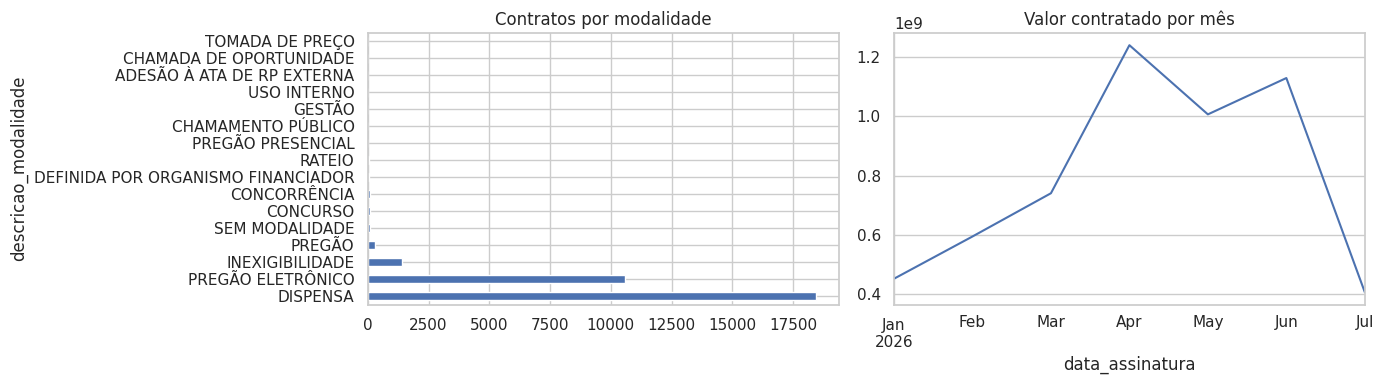

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fato_contrato["descricao_modalidade"].value_counts().plot.barh(ax=axes[0])
axes[0].set_title("Contratos por modalidade")

fato_contrato.groupby(fato_contrato["data_assinatura"].dt.to_period("M"))["valor_contratado"].sum().plot(ax=axes[1])
axes[1].set_title("Valor contratado por mês")
plt.tight_layout()
plt.show()


## 2. Modelo 1 — Detecção de Anomalias Contratuais (Isolation Forest)

/home/jovyan/work/models/anomaly_detection.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


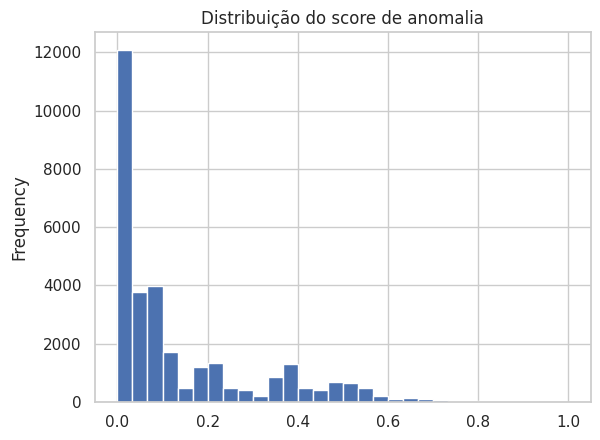

In [6]:
from models.anomaly_detection import (
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, BOOLEAN_FEATURES,
    load_features, build_pipeline, score_anomalies,
)

df_features = load_features(conn)
features = df_features[NUMERIC_FEATURES + CATEGORICAL_FEATURES + BOOLEAN_FEATURES]

pipeline = build_pipeline(contamination=0.05)
pipeline.fit(features)
df_features["score_anomalia"] = score_anomalies(pipeline, features)

df_features["score_anomalia"].plot.hist(bins=30, title="Distribuição do score de anomalia")
plt.show()


### Avaliação qualitativa (sem ground-truth)
Como não há rótulos de anomalia pré-definidos, comparamos o score do modelo com uma
heurística simples de controle interno: contratos de **dispensa/inexigibilidade** com
**valor acima do percentil 95**. Espera-se correlação positiva, mas não perfeita — o
modelo deve capturar padrões adicionais que a heurística isolada não vê.

In [7]:
percentil_95 = df_features["valor_contratado"].quantile(0.95)
df_features["heuristica_suspeita"] = (
    df_features["descricao_modalidade"].isin(["DISPENSA", "INEXIGIBILIDADE"])
    & (df_features["valor_contratado"] >= percentil_95)
)

print(df_features.groupby("heuristica_suspeita")["score_anomalia"].describe())

top10 = df_features.nlargest(10, "score_anomalia")[
    ["sk_contrato", "valor_contratado", "descricao_modalidade", "tipo_objeto", "score_anomalia"]
]
top10


                        count  mean  std  min  25%  50%  75%  max
heuristica_suspeita                                              
False               30,878.00  0.14 0.17 0.00 0.01 0.06 0.20 0.96
True                   290.00  0.57 0.19 0.21 0.45 0.55 0.68 1.00


,sk_contrato,valor_contratado,descricao_modalidade,tipo_objeto,score_anomalia
16040,16175,"19,803,495.36",DISPENSA,Locação/Terceirização de Mão-de-obra,1.00
27858,28000,"21,906,466.08",DISPENSA,Locação/Terceirização de Mão-de-obra,1.00
16022,16158,"14,982,406.08",DISPENSA,Locação/Terceirização de Mão-de-obra,0.99
22735,22872,"16,514,232.36",DISPENSA,Locação/Terceirização de Mão-de-obra,0.99
16023,16159,"13,486,566.00",DISPENSA,Locação/Terceirização de Mão-de-obra,0.99
15983,16118,"11,120,782.80",DISPENSA,Locação/Terceirização de Mão-de-obra,0.97
26314,26459,"179,980,000.00",DISPENSA,Obras e Serviços de Engenharia,0.97
3853,3962,"16,758,014.40",CONCORRÊNCIA,Obras e Serviços de Engenharia,0.96
16002,16138,"8,974,050.60",DISPENSA,Locação/Terceirização de Mão-de-obra,0.95
22605,22743,"7,726,212.12",DISPENSA,Locação/Terceirização de Mão-de-obra,0.94


**Recomendação de uso:** o score de anomalia deve ser tratado como um indicador de
priorização para análise humana (equipe de controle interno), não como uma classificação
definitiva de irregularidade — é assim que o pipeline de produção o utiliza (grava o score
em `dw.fato_contrato.score_anomalia` e o relatório narrativo destaca o top-10 para revisão).

## 3. Modelo 2 — Previsão de Pagamentos Trimestrais (XGBoost, regressão quantílica)

In [8]:
from models.payment_forecast import load_quarterly_history, load_valor_contratado_acumulado, build_features, FEATURE_COLUMNS

history = load_quarterly_history(conn)
contratado_acumulado = load_valor_contratado_acumulado(conn)
df_quarters = build_features(history, contratado_acumulado)

print(f"{len(df_quarters)} observações órgão-trimestre carregadas")
df_quarters.head()


/home/jovyan/work/models/payment_forecast.py:48: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


188 observações órgão-trimestre carregadas


/home/jovyan/work/models/payment_forecast.py:61: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,sk_orgao,codigo_orgao,nome_orgao,ano,trimestre,valor_total,valor_contratado_acumulado,sequencial_trimestre,ano_eleitoral,valor_lag1,valor_mesmo_trimestre_ano_anterior
0,1,01000000,ASSEMBLEIA LEGISLATIVA,2026,1,"188,000,116.16",0.00,8105,1,NaN,NaN
1,1,01000000,ASSEMBLEIA LEGISLATIVA,2026,2,"163,445,515.22",0.00,8106,1,"188,000,116.16",NaN
2,2,01200001,FUNDO DE PREVIDENCIA PARLAMENTAR DA ASSEMB LEG...,2026,1,"3,045,425.02",0.00,8105,1,NaN,NaN
3,2,01200001,FUNDO DE PREVIDENCIA PARLAMENTAR DA ASSEMB LEG...,2026,2,"2,775,175.16",0.00,8106,1,"3,045,425.02",NaN
4,3,02000000,TRIBUNAL DE CONTAS DO ESTADO,2026,1,"59,654,376.40",0.00,8105,1,NaN,NaN


### Backtest (avaliação out-of-sample)
Para os órgãos com histórico suficiente, reservamos o **último trimestre disponível** de
cada série como teste e treinamos com o restante — replicando o cenário real de previsão
"um trimestre à frente".

In [9]:
import numpy as np
import xgboost as xgb

train_rows, test_rows = [], []
for sk_orgao, grp in df_quarters.dropna(subset=FEATURE_COLUMNS).groupby("sk_orgao"):
    grp = grp.sort_values(["ano", "trimestre"])
    if len(grp) < 4:
        continue
    train_rows.append(grp.iloc[:-1])
    test_rows.append(grp.iloc[[-1]])

if train_rows:
    train_df = pd.concat(train_rows)
    test_df = pd.concat(test_rows)

    modelos = {}
    for alpha in (0.1, 0.5, 0.9):
        m = xgb.XGBRegressor(
            objective="reg:quantileerror", quantile_alpha=alpha,
            n_estimators=150, max_depth=3, learning_rate=0.1, random_state=42,
        )
        m.fit(train_df[FEATURE_COLUMNS], train_df["valor_total"])
        modelos[alpha] = m

    pred_p50 = modelos[0.5].predict(test_df[FEATURE_COLUMNS])
    pred_p10 = modelos[0.1].predict(test_df[FEATURE_COLUMNS])
    pred_p90 = modelos[0.9].predict(test_df[FEATURE_COLUMNS])

    mae = np.mean(np.abs(pred_p50 - test_df["valor_total"]))
    mape = np.mean(np.abs(pred_p50 - test_df["valor_total"]) / test_df["valor_total"].replace(0, np.nan)) * 100
    coverage = np.mean((test_df["valor_total"] >= pred_p10) & (test_df["valor_total"] <= pred_p90)) * 100

    print(f"MAE:  R$ {mae:,.2f}")
    print(f"MAPE: {mape:.1f}%")
    print(f"Cobertura do intervalo [p10, p90]: {coverage:.1f}% (ideal: ~80%)")
else:
    print("Histórico insuficiente para backtest com os dados atualmente carregados no DW.\n"
          "Aumente EXTRACT_START_DATE no .env e reprocesse Bronze/Silver/Gold para obter mais trimestres.")


Histórico insuficiente para backtest com os dados atualmente carregados no DW.
Aumente EXTRACT_START_DATE no .env e reprocesse Bronze/Silver/Gold para obter mais trimestres.


## 4. Conclusões

- O **Modelo 1** prioriza contratos para revisão manual com base em desvios estatísticos
  multivariados (valor, modalidade, tipo de objeto, vigência, emergência e histórico do
  credor) — mais rico que uma regra fixa isolada.
- O **Modelo 2** depende fortemente da profundidade do histórico carregado no DW. Com poucos
  trimestres, o pipeline recorre automaticamente a uma previsão ingênua (ver
  `models/payment_forecast.py::MIN_QUARTERS_FOR_ML`); para resultados robustos, recomenda-se
  carregar ao menos 2 anos de histórico (`EXTRACT_START_DATE=2022-01-01` ou anterior).
- Os resultados destes dois modelos alimentam `dag_ml_inference`, que grava os scores/
  previsões no DW e aciona o gerador de relatório narrativo (`models/report_generator.py`).


In [10]:
conn.close()